In [1]:
import matplotlib.pyplot as plt
plt.style.use('thesis')
import numpy as np

In [2]:
base = '/avatar/vmehta/sfh_500_10bins_20260427_112623/finalmodel/train_sfh_1100_6bins_20260423_112538_snr100__test_sfh_500_10bins_20260427_112623_snr100'
wavs = np.load('/home/vmehta/honours-project/code/data/wavelengths.npy')
spec6 = np.load('/home/vmehta/honours-project/code/data/sfh_sixbins_spectra.npy')
spec10 = np.load('/home/vmehta/honours-project/code/data/sfh_tenbins_spectra.npy')
pred = np.load(f'{base}_pred.npy')
true = np.load(f'{base}_true.npy')

In [8]:
def moving_average(x, w):
        """Returns the moving average of the input array."""
        return np.convolve(x, np.ones(w), 'same') / w

def normalize(v):
    s_flat = v / moving_average(v, 100)
    return s_flat * moving_average(np.ones_like(s_flat), 100)  # dealing with edges

norm6 = [normalize(spec) for spec in spec6]
norm10 = [normalize(spec) for spec in spec10]

pred_spec = pred @ norm6
true_spec = true @ norm10
residual = pred_spec - true_spec

NameError: name 'spec6' is not defined

In [31]:
young = []
mixed = []
old = []

for n, i in enumerate(true):
    if np.sum(i[-2:]) > 0.5:
        old.append(n)
    elif np.sum(i[:4]) > 0.5:
        young.append(n)
    else:
        mixed.append(n)

In [32]:
edges6 = np.log10(np.r_[np.array([0.1])*1e6, np.logspace(7, 10.15, 6)])
centers6 = (edges6[:-1] + edges6[1:]) / 2
widths6 = edges6[1:] - edges6[:-1]
edges10 = np.log10(np.r_[np.array([0.1])*1e6, np.logspace(7, 10.15, 10)])
centers10 = (edges10[:-1] + edges10[1:]) / 2
widths10 = edges10[1:] - edges10[:-1]

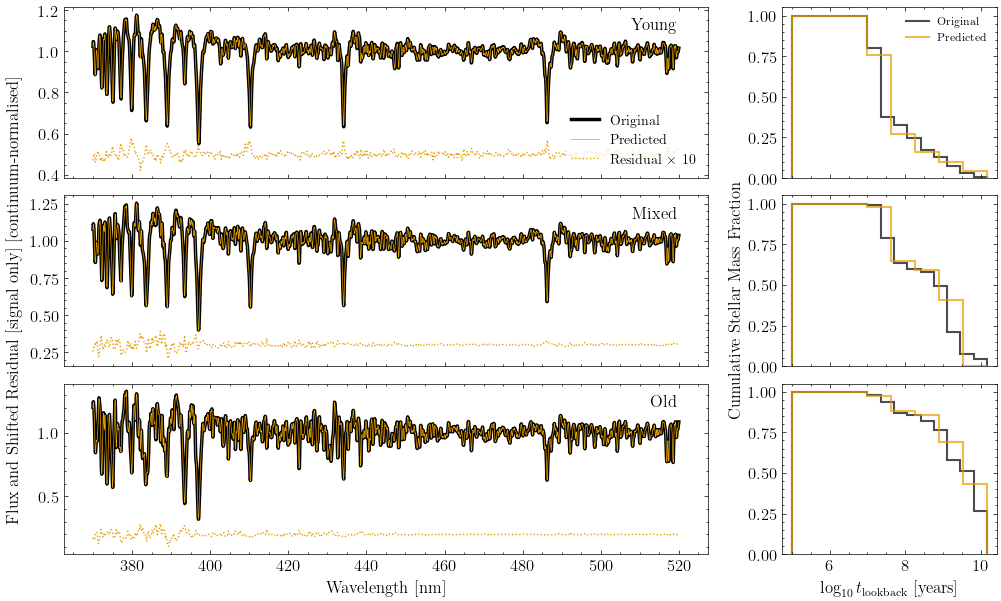

In [33]:
a = 59
b = 32
c = 183

fig, ax = plt.subplots(3, 2, figsize=(10, 6), sharex='col', constrained_layout=True, gridspec_kw={'width_ratios': [3, 1], 'wspace': 0.08})

ax[0, 0].plot(wavs/10, true_spec[a], 'k', linewidth=2.5, label='Original')
ax[0, 0].plot(wavs/10, pred_spec[a], 'C0', linewidth=0.5, label='Predicted')
ax[0, 0].plot(wavs/10, residual[a]*10 + 0.5, 'C0:', linewidth=1, label='Residual $\\times$ 10')
ax[0, 0].legend(fontsize=10, loc='lower right', frameon=True, edgecolor='white', facecolor='white', framealpha=0.8)
ax[0,0].text(0.95, 0.85, 'Young', transform=ax[0, 0].transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')

ax[0, 1].stairs(np.flip(np.cumsum(np.flip(true[a]))), edges10, color='k', alpha=0.7, linewidth=1.5, label='Original')
ax[0, 1].stairs(np.flip(np.cumsum(np.flip(pred[a]))), edges6, color='C0', alpha=0.7, linewidth=1.5, label='Predicted')
ax[0, 1].legend(fontsize=8, loc='upper right')

ax[1, 0].plot(wavs/10, true_spec[b], 'k', linewidth=2.5, label='Original')
ax[1, 0].plot(wavs/10, pred_spec[b], 'C0', linewidth=0.5, label='Predicted')
ax[1, 0].plot(wavs/10, residual[b]*10 + 0.3, 'C0:', linewidth=1, label='Residual $\\times$ 10')
ax[1, 0].text(0.95, 0.85, 'Mixed', transform=ax[1, 0].transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')

ax[1, 1].stairs(np.flip(np.cumsum(np.flip(true[b]))), edges10, color='k', alpha=0.7, linewidth=1.5, label='Original')
ax[1, 1].stairs(np.flip(np.cumsum(np.flip(pred[b]))), edges6, color='C0', alpha=0.7, linewidth=1.5, label='Predicted')

ax[2, 0].plot(wavs/10, true_spec[c], 'k', linewidth=2.5, label='Original')
ax[2, 0].plot(wavs/10, pred_spec[c], 'C0', linewidth=0.5, label='Predicted')
ax[2, 0].plot(wavs/10, residual[c]*10 + 0.2, 'C0:', linewidth=1, label='Residual')
ax[2, 0].text(0.95, 0.85, 'Old', transform=ax[2, 0].transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')
ax[2, 0].set_xlabel('Wavelength [nm]', fontsize=12)

ax[2, 1].stairs(np.flip(np.cumsum(np.flip(true[c]))), edges10, color='k', alpha=0.7, linewidth=1.5, label='Original')
ax[2, 1].stairs(np.flip(np.cumsum(np.flip(pred[c]))), edges6, color='C0', alpha=0.7, linewidth=1.5, label='Predicted')
ax[2, 1].set_xlabel(f'$\\log_{{10}}t_\\mathrm{{lookback}}$ [years]', fontsize=12)

fig.supylabel('Flux and Shifted Residual [signal only] [continuum-normalised]', fontsize=12)
fig.text(0.735, 0.5, 'Cumulative Stellar Mass Fraction', va='center', ha='center', rotation='vertical', fontsize=12)

plt.savefig('/home/vmehta/honours-project/thesis/figures/mismatched.pdf', format='pdf')
plt.show()

In [9]:
import sys
from pathlib import Path

# Ensure the project src directory is importable in this notebook kernel.
src_root = Path('/home/vmehta/honours-project/code/src')
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from AnniesLasso.thecannon.vectorizer.polynomial import PolynomialVectorizer
from AnniesLasso.thecannon.model import CannonModel


In [36]:
def fit_and_return_spectrum(
    fits_path,
    training_base,
    spectra_base,
    *,
    spectra_suffix='snr1000',
    trim_start=71,
    continuum_window=100,
    polynomial_order=2,
    label_names=('1', '2', '3', '4', '5', '6'),
):
    """Fit a real spectrum and return the fitted Cannon spectrum."""
    import sys
    from pathlib import Path

    from astropy.io import fits

    src_root = Path('/home/vmehta/honours-project/code/src')
    if str(src_root) not in sys.path:
        sys.path.insert(0, str(src_root))

    from AnniesLasso.thecannon.vectorizer.polynomial import PolynomialVectorizer
    from AnniesLasso.thecannon.model import CannonModel

    def moving_average(x, w):
        return np.convolve(x, np.ones(w), 'same') / w

    def normalize(v):
        s_flat = v / moving_average(v, continuum_window)
        return s_flat * moving_average(np.ones_like(s_flat), continuum_window)

    with fits.open(fits_path) as hdul:
        flux = hdul[2].data[180:1776]
        invar = hdul[3].data[180:1776]

    continuum = moving_average(flux, continuum_window)
    edge_factor = moving_average(np.ones_like(flux), continuum_window)
    final_s = flux / continuum * edge_factor
    scale = edge_factor / continuum
    ivar_final = invar / (scale ** 2)

    train_labels = fits.getdata(f'{training_base}_labels.fits')
    new_wavs = np.load(f'{training_base}_wavelength.npy')[trim_start:]
    new_spec = np.load(f'{training_base}_{spectra_suffix}_spectra.npy')[:, trim_start:]
    new_ivar = np.load(f'{training_base}_{spectra_suffix}_invvar.npy')[:, trim_start:]
    norm_spectra = [normalize(spec)[trim_start:] for spec in np.load(spectra_base)]

    vectorizer = PolynomialVectorizer(list(label_names), polynomial_order)
    model = CannonModel(train_labels, new_spec, new_ivar, vectorizer=vectorizer, dispersion=new_wavs)
    model.train()

    labels, *_ = model.test(final_s, ivar_final)
    fitted_spectrum = labels @ norm_spectra
    return fitted_spectrum[0]


In [37]:
s_old = fit_and_return_spectrum(
    fits_path='/home/vmehta/honours-project/code/data/SDSS_588010136802427000_repack.fits',
    training_base='/avatar/vmehta/sfh_1000_6bins_20260512_162011/sfh_1000_6bins_20260512_162011',
    spectra_base='/home/vmehta/honours-project/code/data/sdss_smoothed_spectra.npy')
s_young = fit_and_return_spectrum(
    fits_path='/home/vmehta/honours-project/code/data/SDSS_587742903401119752_repack.fits',
    training_base='/avatar/vmehta/sfh_1000_6bins_20260513_173130/sfh_1000_6bins_20260513_173130',
    spectra_base='/home/vmehta/honours-project/code/data/sdss_smoothed_spectra2.npy')

2026-05-13 18:21:44,715 [INFO] Training 6-label CannonModel with 1000 stars and 1596 pixels/star


stty: 'standard input': Inappropriate ioctl for device
2026-05-13 18:21:44,721 [DEBUG] Couldn't get screen size. Progressbar may look odd.


[==========================================================================================================] 100% (170s)                               


stty: 'standard input'2026-05-13 18:24:34,932 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-05-13 18:24:34,933 [INFO] Running test step on 1 spectra


[=                                                                                                   ] 100% (0s)                         


...

[                                                                                                    ]   0% (1/1596)                          

: Inappropriate ioctl for device


[==========================================================================================================] 100% (173s)                               


stty: 'standard input'2026-05-13 18:27:27,570 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-05-13 18:27:27,571 [INFO] Running test step on 1 spectra


[=                                                                                                   ] 100% (0s)                         


In [40]:
from astropy.io import fits

flux_old = fits.getdata('/home/vmehta/honours-project/code/data/SDSS_588010136802427000_repack.fits', ext=2)[180:1776]
flux_young = fits.getdata('/home/vmehta/honours-project/code/data/SDSS_587742903401119752_repack.fits', ext=2)[180:1776]

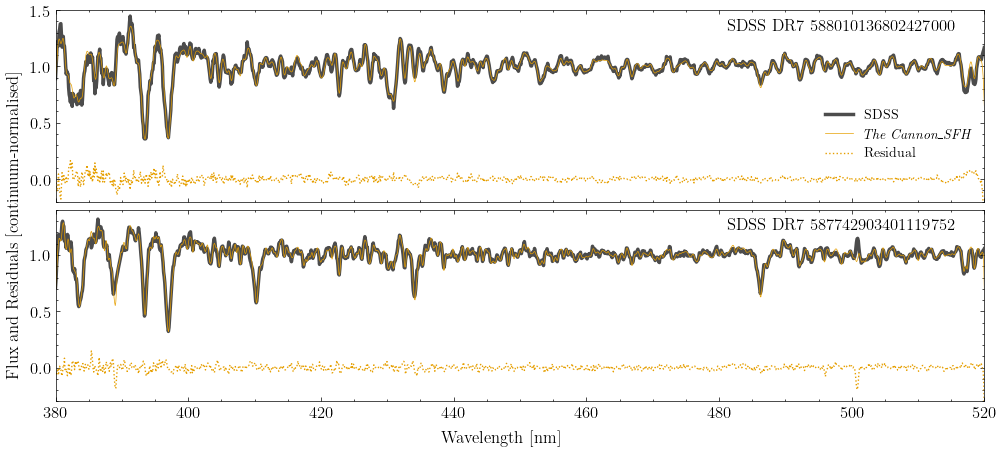

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True, constrained_layout=True)

ax[0].plot(new_wavs/10, normalize(flux_old), 'k', linewidth=2.5, alpha=0.7, label='SDSS')
ax[0].plot(new_wavs/10, s_old, 'C0', linewidth=0.5, label='\\textit{The Cannon_SFH}')
ax[0].plot(new_wavs/10, s_old - normalize(flux_old), 'C0:', lw=1, label='Residual')

ax[1].plot(new_wavs/10, normalize(flux_young), 'k', linewidth=2.5, alpha=0.7, label='Original')
ax[1].plot(new_wavs/10, s_young, 'C0', linewidth=0.5, label='Predicted')
ax[1].plot(new_wavs/10, s_young - normalize(flux_young), 'C0:', lw=1, label='Residual')

ax[0].set_ylim(-0.2, 1.5)
ax[1].set_ylim(-0.3, 1.4)
ax[0].set_xlim(380,520)
ax[0].text(0.97, 0.88, 'SDSS DR7 588010136802427000', transform=ax[0].transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')
ax[1].text(0.97, 0.88, 'SDSS DR7 587742903401119752', transform=ax[1].transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')
ax[0].legend(fontsize=10, loc='center right', bbox_to_anchor=(1.0, 0.35), frameon=True, edgecolor='white', facecolor='white', framealpha=0.8)

fig.supylabel('Flux and Residuals [continuum-normalised]', fontsize=12)
fig.supxlabel('Wavelength [nm]', fontsize=12)
#plt.savefig('/home/vmehta/honours-project/thesis/figures/sdss-test.pdf', format='pdf')
plt.show()